<a href="https://colab.research.google.com/github/sanjana19991118/python_ml/blob/main/Data_Preprocessing_Graded_Assignment_Sanjana_Vinay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Preprocessing and Dataset Preparation for Machine Learning



In [2]:
import pandas as pd
from tabulate import tabulate
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
df = pd.read_csv('/content/fifa21 datatset.csv')

In [ ]:
# df

,ID,Name,LongName,photoUrl,playerUrl,Nationality,Age,↓OVA,POT,Club,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,33,93,93,\n\n\n\nFC Barcelona,...,Medium,Low,5 ★,85,92,91,95,38,65,771
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,35,92,92,\n\n\n\nJuventus,...,High,Low,5 ★,89,93,81,89,35,77,562
2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,\n\n\n\nAtlético Madrid,...,Medium,Medium,3 ★,87,92,78,90,52,90,150
3,192985,K. De Bruyne,Kevin De Bruyne,https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,29,91,91,\n\n\n\nManchester City,...,High,High,4 ★,76,86,93,88,64,78,207
4,190871,Neymar Jr,Neymar da Silva Santos Jr.,https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,28,91,91,\n\n\n\nParis Saint-Germain,...,High,Medium,5 ★,91,85,86,94,36,59,595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18974,247223,Xia Ao,Ao Xia,https://cdn.sofifa.com/players/247/223/21_60.png,http://sofifa.com/player/247223/ao-xia/210006/,China PR,21,47,55,\n\n\n\nWuhan Zall,...,Medium,Medium,1 ★,64,28,26,38,48,51,NaN
18975,258760,B. Hough,Ben Hough,https://cdn.sofifa.com/players/258/760/21_60.png,http://sofifa.com/player/258760/ben-hough/210006/,England,17,47,67,\n\n\n\nOldham Athletic,...,Medium,Medium,1 ★,64,40,48,49,35,45,NaN
18976,252757,R. McKinley,Ronan McKinley,https://cdn.sofifa.com/players/252/757/21_60.png,http://sofifa.com/player/252757/ronan-mckinley...,England,18,47,65,\n\n\n\nDerry City,...,Medium,Medium,1 ★,63,39,44,46,40,53,NaN
18977,243790,Wang Zhen'ao,Zhen'ao Wang,https://cdn.sofifa.com/players/243/790/21_60.png,http://sofifa.com/player/243790/zhenao-wang/21...,China PR,20,47,57,\n\n\n\nDalian YiFang FC,...,Medium,Medium,1 ★,58,49,41,49,30,44,NaN


TASK A - Dataset Understanding



1.   Describe the Dataset
       

*   No of Records
*   No of features
*   Target Variable






In [3]:
print(df.shape)
# Number of Records in the Dataset
print('Number of Records', df.shape[0])

(18979, 77)
Number of Records 18979


In [4]:
# Length
print('Length', len(df))
print(df.describe())

Length 18979
                  ID           Age          ↓OVA           POT           BOV  \
count   18979.000000  18979.000000  18979.000000  18979.000000  18979.000000   
mean   226403.384794     25.194109     65.718636     71.136414     66.751726   
std     27141.054157      4.710520      6.968999      6.114635      6.747193   
min        41.000000     16.000000     47.000000     47.000000     48.000000   
25%    210135.000000     21.000000     61.000000     67.000000     62.000000   
50%    232418.000000     25.000000     66.000000     71.000000     67.000000   
75%    246922.500000     29.000000     70.000000     75.000000     71.000000   
max    259216.000000     53.000000     93.000000     95.000000     93.000000   

          Attacking      Crossing     Finishing  Heading Accuracy  \
count  18979.000000  18979.000000  18979.000000      18979.000000   
mean     248.938142     49.688392     45.842405         51.942726   
std       74.299428     18.131153     19.567081         17.

In [5]:
# Number of features
print("Total Features", df.shape[1])

Total Features 77


In [6]:
# Target Variable - ↓OVA (Overall Rating) is the target variable.
target = '↓OVA'
print("Target Variable:", target)

Target Variable: ↓OVA


In [ ]:
# dtype_summary = df.dtypes.value_counts().reset_index()
# dtype_summary.columns = ['Dtype', 'Count']
# feature_df = pd.DataFrame({'Feature': df.columns, 'Data Type': df.dtypes.values, 'Unique Values': df.nunique().values})
# print(tabulate(feature_df, headers='keys', tablefmt='grid', showindex=False))


2.   Identify attribute types

Classify each feature into:
*   Nominal attributes
*   Ordinal attributes
*   Numeric attributes
      * Discrete
      * Continuous







In [7]:
# Feature Classification

nominal_attributes = [
    "ID", "Name", "LongName", "photoUrl", "playerUrl", "Nationality", "Club",
    "Positions", "Preferred Foot", "Best Position", "Joined", "Loan Date End", "Contract"
]

ordinal_attributes = [
    "W/F", "SM", "IR", "A/W", "D/W"
]

discrete_attributes = [
    "Age", "↓OVA", "POT", "BOV", "Attacking", "Crossing", "Finishing",
    "Heading Accuracy", "Short Passing", "Volleys", "Skill", "Dribbling",
    "Curve", "FK Accuracy", "Long Passing", "Ball Control", "Movement",
    "Acceleration", "Sprint Speed", "Agility", "Reactions", "Balance",
    "Power", "Shot Power", "Jumping", "Stamina", "Strength", "Long Shots",
    "Mentality", "Aggression", "Interceptions", "Positioning", "Vision",
    "Penalties", "Composure", "Defending", "Marking", "Standing Tackle",
    "Sliding Tackle", "Goalkeeping", "GK Diving", "GK Handling", "GK Kicking",
    "GK Positioning", "GK Reflexes", "Total Stats", "Base Stats", "PAC",
    "SHO", "PAS", "DRI", "DEF", "PHY", "Hits" # 'Hits' is discrete but needs cleaning from string format
]

continuous_attributes = [
    "Height",
    "Weight",
    "Value",
    "Wage",
    "Release Clause"
]

# 1. Summary Count Table
print("\n" + "="*55)
print(" Feature Classification Summary")
print("="*55)

summary = pd.DataFrame({
    'Attribute Type': ['Nominal', 'Ordinal', 'Numeric - Discrete', 'Numeric - Continuous', 'Total'],
    'Count': [len(nominal_attributes), len(ordinal_attributes),
            len(discrete_attributes), len(continuous_attributes),
              len(nominal_attributes) + len(ordinal_attributes) +
              len(discrete_attributes) + len(continuous_attributes)]
})

print(tabulate(summary, headers='keys', tablefmt='grid', showindex=False))

# -- 2. Nominal
print("\n Nominal attributes")
print(tabulate(pd.DataFrame({'#': range(1, len(nominal_attributes) + 1), 'Feature': nominal_attributes}),
               headers='keys', tablefmt='grid', showindex=False))

# -- 3. Ordinal
print("\n Ordinal attributes")
print(tabulate(pd.DataFrame({
    '#': range(1,len(ordinal_attributes)+1),
    'Feature': ordinal_attributes,
    'Order': ['1★–5★','1★–5★','1★–5★','Low→Med→High','Low→Med→High']
}), headers='keys', tablefmt='grid', showindex=False))

# ── 4. Numeric Discrete ────────────────────────────────────
print("\n NUMERIC — DISCRETE")
print(tabulate(pd.DataFrame({'#': range(1,len(discrete_attributes)+1), 'Feature': discrete_attributes}),
               headers='keys', tablefmt='grid', showindex=False))


# ── 5. Numeric Continuous ──────────────────────────────────
print("\n NUMERIC — CONTINUOUS")
print(tabulate(pd.DataFrame({
    '#': range(1,len(continuous_attributes)+1),
    'Feature': continuous_attributes,
    'Raw Format': ['170cm','72kg','€103.5M','€560K','€138.4M']
}), headers='keys', tablefmt='grid', showindex=False))


 Feature Classification Summary
+----------------------+---------+
| Attribute Type       |   Count |
+======================+=========+
| Nominal              |      13 |
+----------------------+---------+
| Ordinal              |       5 |
+----------------------+---------+
| Numeric - Discrete   |      54 |
+----------------------+---------+
| Numeric - Continuous |       5 |
+----------------------+---------+
| Total                |      77 |
+----------------------+---------+

 Nominal attributes
+-----+----------------+
|   # | Feature        |
+=====+================+
|   1 | ID             |
+-----+----------------+
|   2 | Name           |
+-----+----------------+
|   3 | LongName       |
+-----+----------------+
|   4 | photoUrl       |
+-----+----------------+
|   5 | playerUrl      |
+-----+----------------+
|   6 | Nationality    |
+-----+----------------+
|   7 | Club           |
+-----+----------------+
|   8 | Positions      |
+-----+----------------+
|   9 | Preferre

3. Provide a data dictionary table

Example format:

**Feature Type Description**

In [ ]:

# ── Data Dictionary ─────────────────────────────────────
print("\n" + "="*55)
print("   DATA DICTIONARY")
print("="*55)

data_dict = [
  ["ID",               "Nominal",             "Unique FIFA player ID — not used for modelling"],
  ["Name",             "Nominal",             "Short display name of the player"],
  ["LongName",         "Nominal",             "Full legal name of the player"],
  ["photoUrl",         "Nominal (URL)",       "URL to player photo image"],
  ["playerUrl",        "Nominal (URL)",       "URL to player's sofifa profile page"],
  ["Nationality",      "Nominal",             "Player's country (164 unique values)"],
  ["Age",              "Discrete",            "Player age in years (range 16–53)"],
  ["↓OVA",            "Discrete — TARGET",   "Overall rating (0–100); main regression target"],
  ["POT",              "Discrete",            "Potential rating; max OVA a player can reach"],
  ["Club",             "Nominal",             "Current club name (682 unique clubs)"],
  ["Contract",         "Nominal",             "Contract period e.g. '2019 ~ 2023'"],
  ["Positions",        "Nominal",             "All positions the player can play e.g. ST, CB"],
  ["Height",           "Continuous*",         "Player height in cm (stored as string e.g. 170cm)"],
  ["Weight",           "Continuous*",         "Player weight in kg (stored as string e.g. 72kg)"],
  ["Preferred Foot",   "Nominal (Binary)",    "Dominant foot — Left or Right"],
  ["BOV",              "Discrete",            "Best OVA achieved in the player's best position"],
  ["Best Position",    "Nominal",             "Best position on pitch (15 categories e.g. ST, GK)"],
  ["Joined",           "Nominal (Date)",      "Date the player joined their current club"],
  ["Loan Date End",    "Nominal (Date)",      "End date of loan spell (if applicable)"],
  ["Value",            "Continuous*",         "Market value in euros e.g. €103.5M"],
  ["Wage",             "Continuous*",         "Weekly wage in euros e.g. €560K"],
  ["Release Clause",   "Continuous*",         "Release clause fee in euros"],
  ["Attacking",        "Discrete",            "Composite score of all attacking sub-attributes"],
  ["Crossing",         "Discrete",            "Cross delivery accuracy (0–100)"],
  ["Finishing",        "Discrete",            "Goal-scoring finishing ability (0–100)"],
  ["Heading Accuracy", "Discrete",            "Accuracy when heading the ball (0–100)"],
  ["Short Passing",    "Discrete",            "Short pass accuracy (0–100)"],
  ["Volleys",          "Discrete",            "Volley striking ability (0–100)"],
  ["Skill",            "Discrete",            "Composite score of all skill sub-attributes"],
  ["Dribbling",        "Discrete",            "Ball dribbling ability (0–100)"],
  ["Curve",            "Discrete",            "Ability to curve or bend the ball (0–100)"],
  ["FK Accuracy",      "Discrete",            "Free kick accuracy (0–100)"],
  ["Long Passing",     "Discrete",            "Long pass accuracy (0–100)"],
  ["Ball Control",     "Discrete",            "First touch and ball control (0–100)"],
  ["Movement",         "Discrete",            "Composite score of all movement sub-attributes"],
  ["Acceleration",     "Discrete",            "Rate of speed increase (0–100)"],
  ["Sprint Speed",     "Discrete",            "Maximum running speed (0–100)"],
  ["Agility",          "Discrete",            "Quickness of turns and movement (0–100)"],
  ["Reactions",        "Discrete",            "Reaction speed to in-game events (0–100)"],
  ["Balance",          "Discrete",            "Balance while moving or dribbling (0–100)"],
  ["Power",            "Discrete",            "Composite score of all power sub-attributes"],
  ["Shot Power",       "Discrete",            "Power behind a shot (0–100)"],
  ["Jumping",          "Discrete",            "Jump height and timing (0–100)"],
  ["Stamina",          "Discrete",            "Endurance over 90 minutes (0–100)"],
  ["Strength",         "Discrete",            "Physical strength in duels (0–100)"],
  ["Long Shots",       "Discrete",            "Long-range shot accuracy (0–100)"],
  ["Mentality",        "Discrete",            "Composite score of all mentality sub-attributes"],
  ["Aggression",       "Discrete",            "Aggression in tackles and duels (0–100)"],
  ["Interceptions",    "Discrete",            "Ability to intercept passes (0–100)"],
  ["Positioning",      "Discrete",            "Attacking positional awareness (0–100)"],
  ["Vision",           "Discrete",            "Ability to spot passing opportunities (0–100)"],
  ["Penalties",        "Discrete",            "Penalty kick accuracy (0–100)"],
  ["Composure",        "Discrete",            "Calmness under pressure (0–100)"],
  ["Defending",        "Discrete",            "Composite score of all defending sub-attributes"],
  ["Marking",          "Discrete",            "Ability to mark opponents (0–100)"],
  ["Standing Tackle",  "Discrete",            "Standing tackle accuracy (0–100)"],
  ["Sliding Tackle",   "Discrete",            "Sliding tackle accuracy (0–100)"],
  ["Goalkeeping",      "Discrete",            "Composite score of all GK sub-attributes"],
  ["GK Diving",        "Discrete",            "Goalkeeper diving ability (0–100)"],
  ["GK Handling",      "Discrete",            "Goalkeeper ball handling (0–100)"],
  ["GK Kicking",       "Discrete",            "Goalkeeper kicking ability (0–100)"],
  ["GK Positioning",   "Discrete",            "Goalkeeper positioning awareness (0–100)"],
  ["GK Reflexes",      "Discrete",            "Goalkeeper reflex speed (0–100)"],
  ["Total Stats",      "Discrete",            "Sum of all individual skill ratings"],
  ["Base Stats",       "Discrete",            "Sum of 6 core stats: PAC+SHO+PAS+DRI+DEF+PHY"],
  ["W/F",              "Ordinal",             "Weak foot rating: 1★ to 5★"],
  ["SM",               "Ordinal",             "Skill moves rating: 1★ to 5★"],
  ["A/W",              "Ordinal",             "Attacking work rate: Low / Medium / High"],
  ["D/W",              "Ordinal",             "Defensive work rate: Low / Medium / High"],
  ["IR",               "Ordinal",             "International reputation: 1★ to 5★"],
  ["PAC",              "Discrete",            "Pace — composite of Acceleration & Sprint Speed"],
  ["SHO",              "Discrete",            "Shooting — composite of shooting attributes"],
  ["PAS",              "Discrete",            "Passing — composite of passing attributes"],
  ["DRI",              "Discrete",            "Dribbling — composite of dribbling attributes"],
  ["DEF",              "Discrete",            "Defending — composite of defending attributes"],
  ["PHY",              "Discrete",            "Physicality — composite of physical attributes"],
  ["Hits",             "Discrete*",           "Times player was searched on sofifa.com"],
]

dd = pd.DataFrame(data_dict, columns=['Feature', 'Type', 'Description'])
print(tabulate(dd, headers='keys', tablefmt='grid', showindex=False, maxcolwidths=[20, 22, 48]))
print("\n* = Stored as string in raw data; requires cleaning before numeric use.")


   DATA DICTIONARY
+------------------+-------------------+--------------------------------------------------+
| Feature          | Type              | Description                                      |
+==================+===================+==================================================+
| ID               | Nominal           | Unique FIFA player ID — not used for modelling   |
+------------------+-------------------+--------------------------------------------------+
| Name             | Nominal           | Short display name of the player                 |
+------------------+-------------------+--------------------------------------------------+
| LongName         | Nominal           | Full legal name of the player                    |
+------------------+-------------------+--------------------------------------------------+
| photoUrl         | Nominal (URL)     | URL to player photo image                        |
+------------------+-------------------+--------------------

Task B - Data Quality Analysis

1. Missing Values

*   Count missing values per column
*   Visualize using heatmap or table

In [8]:
# ─── Style ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.edgecolor': '#444',
    'grid.color': '#333',
    'axes.titlecolor': 'white',
})

BLUE   = '#4e9af1'
ORANGE = '#f4a261'
GREEN  = '#2ec4b6'
RED    = '#e63946'
PURPLE = '#9b59b6'
GOLD   = '#f6c90e'

In [9]:
total_cells    = df.shape[0] * df.shape[1]
total_missing  = df.isnull().sum().sum()
total_complete = total_cells - total_missing

In [10]:
print(f"\n DATASET OVERVIEW")
print(f"  Total Records       : {df.shape[0]}")
print(f"  Total Features      : {df.shape[1]}")
print(f"  Total Cells         : {total_cells}")
print(f"  Total Missing Cells : {total_missing}")
print(f"  Complete Cells      : {total_complete}")
print(f"  Missing Percentage  : {round((total_missing / total_cells) * 100, 2)}%")


 DATASET OVERVIEW
  Total Records       : 18979
  Total Features      : 77
  Total Cells         : 1461383
  Total Missing Cells : 20561
  Complete Cells      : 1440822
  Missing Percentage  : 1.41%


In [11]:
print(f"\n MISSING VALUES PER COLUMN")

missing_df = pd.DataFrame({
    'Feature'          : df.columns,
    'Total Records'    : df.shape[0],
    'Missing Count'    : df.isnull().sum().values,
    'Missing %'        : round((df.isnull().sum() / df.shape[0]) * 100, 2).values,
    'Non-Missing Count': df.notnull().sum().values,
    'Data Type'        : df.dtypes.values
})

 # Sort by missing count descending
missing_df = missing_df.sort_values('Missing Count', ascending=False).reset_index(drop=True)

print(tabulate(missing_df, headers='keys', tablefmt='grid', showindex=False))

# Columns WITH missing values only
print(f"\n COLUMNS WITH MISSING VALUES ONLY")

has_missing = missing_df[missing_df['Missing Count'] > 0]

if has_missing.empty:
    print(" No missing values found in the dataset.")
else:
    print(f"  Total columns with missing values: {len(has_missing)}")
    print(tabulate(has_missing, headers='keys', tablefmt='grid', showindex=False))

# Columns with NO missing values
no_missing = missing_df[missing_df['Missing Count'] == 0]
print(f"\n COLUMNS WITH NO MISSING VALUES : {len(no_missing)}")
print(tabulate(no_missing[['Feature','Missing Count','Missing %']],
               headers='keys', tablefmt='grid', showindex=False))

# Missing value severity classification
print(f"\n MISSING VALUE SEVERITY CLASSIFICATION")

def classify(pct):
    if pct == 0:
        return 'No Missing'
    elif pct <= 5:
        return 'Low  (≤5%)'
    elif pct <= 20:
        return 'Medium (6–20%)'
    else:
        return 'High  (>20%)'

missing_df['Severity'] = missing_df['Missing %'].apply(classify)

severity_summary = missing_df.groupby('Severity')['Feature'].count().reset_index()
severity_summary.columns = ['Severity', 'No. of Features']
print(tabulate(severity_summary, headers='keys', tablefmt='grid', showindex=False))


 MISSING VALUES PER COLUMN
+------------------+-----------------+-----------------+-------------+---------------------+-------------+
| Feature          |   Total Records |   Missing Count |   Missing % |   Non-Missing Count | Data Type   |
+==================+=================+=================+=============+=====================+=============+
| Loan Date End    |           18979 |           17966 |       94.66 |                1013 | object      |
+------------------+-----------------+-----------------+-------------+---------------------+-------------+
| Hits             |           18979 |            2595 |       13.67 |               16384 | object      |
+------------------+-----------------+-----------------+-------------+---------------------+-------------+
| LongName         |           18979 |               0 |        0    |               18979 | object      |
+------------------+-----------------+-----------------+-------------+---------------------+-------------+
| Name   

Visualize using heatmap or table


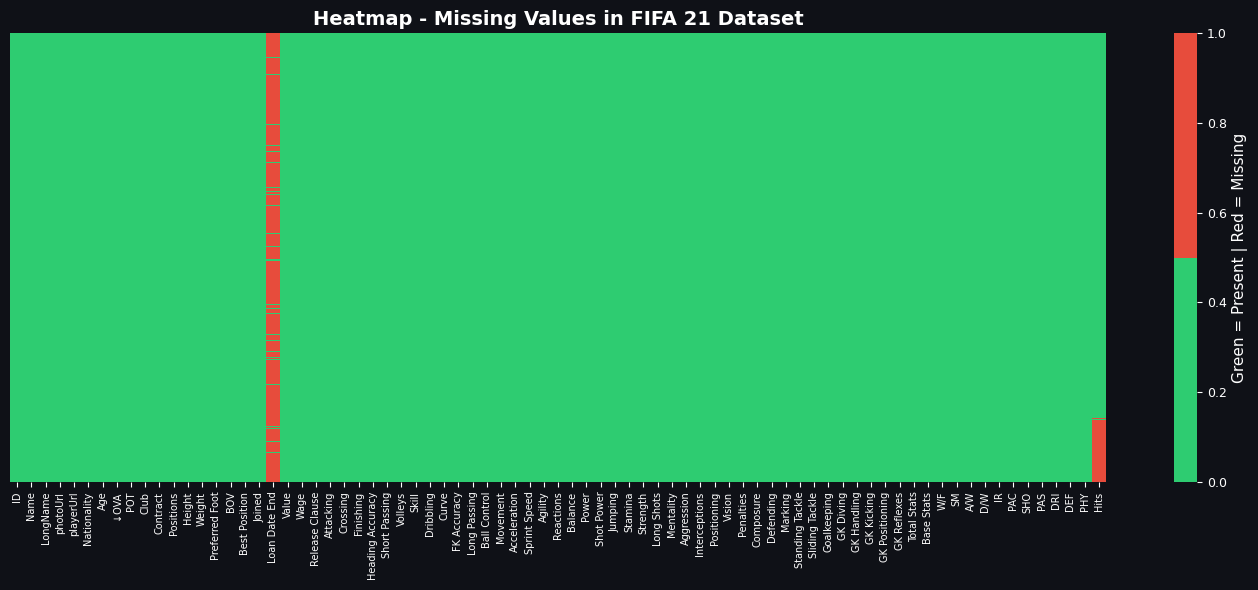

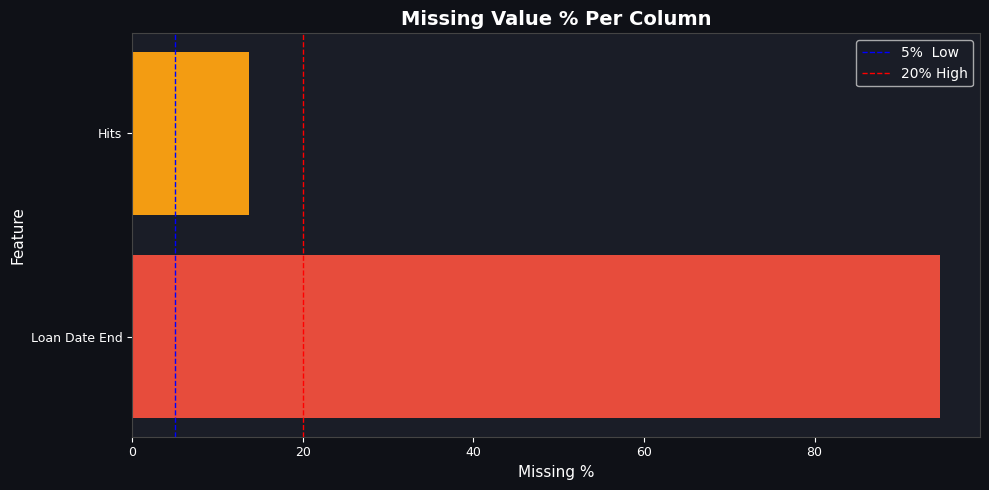

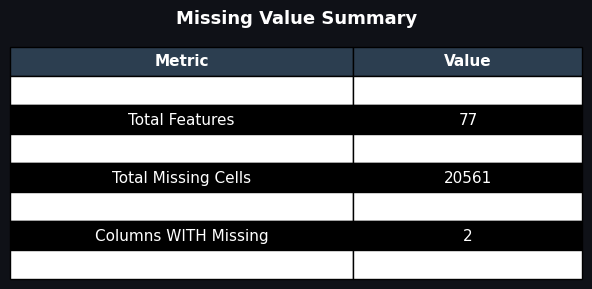

In [12]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# %matplotlib inline

# ── Missing value dataframe ───────────────────────────────
missing_count   = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Feature'      : missing_count.index,
    'Missing Count': missing_count.values,
    'Missing %'    : round(missing_percent, 2).values
}).sort_values('Missing %', ascending=False).reset_index(drop=True)

has_missing = missing_df[missing_df['Missing Count'] > 0]

# ── Heatmap ──────────────────────────────────────
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(),
            cmap=['#2ecc71','#e74c3c'],
            cbar_kws={'label': 'Green = Present | Red = Missing'},
            yticklabels=False,
            xticklabels=True)
plt.title('Heatmap - Missing Values in FIFA 21 Dataset', fontsize=14, fontweight='bold')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

# ── Bar chart ────────────────────────────────────
if has_missing.empty:
    print("No missing values found!")
else:
    plt.figure(figsize=(10, 5))
    colors = ['#e74c3c' if p > 20 else '#f39c12' if p > 5 else '#3498db'
              for p in has_missing['Missing %']]
    plt.barh(has_missing['Feature'], has_missing['Missing %'], color=colors)
    plt.axvline(x=5,  color='blue',  linestyle='--', linewidth=1, label='5%  Low')
    plt.axvline(x=20, color='red',   linestyle='--', linewidth=1, label='20% High')
    plt.title('Missing Value % Per Column', fontsize=14, fontweight='bold')
    plt.xlabel('Missing %')
    plt.ylabel('Feature')
    plt.legend()
    plt.tight_layout()
    plt.show()

# ── Summary Table ────────────────────────────────
total_cells   = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()

summary_data = {
    'Metric': ['Total Records', 'Total Features', 'Total Cells',
               'Total Missing Cells', 'Overall Missing %',
               'Columns WITH Missing', 'Columns WITHOUT Missing'],
    'Value' : [df.shape[0], df.shape[1], total_cells,
               total_missing, f"{(total_missing/total_cells)*100:.2f}%",
               len(has_missing), df.shape[1] - len(has_missing)]
}

plt.figure(figsize=(6, 3))
plt.axis('off')
table = plt.table(
    cellText  = list(zip(summary_data['Metric'], summary_data['Value'])),
    colLabels = ['Metric', 'Value'],
    cellLoc   = 'center',
    loc       = 'center',
    colWidths = [0.6, 0.4]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

for col in range(2):
    table[0, col].set_facecolor('#2c3e50')
    table[0, col].set_text_props(color='white', fontweight='bold')
for row in range(1, 8):
    for col in range(2):
        table[row, col].set_facecolor('black' if row % 2 == 0 else '#ffffff')

plt.title('Missing Value Summary', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Duplicate Records
*   Identify duplicate rows
*   Remove duplicates if necessary

In [ ]:
# ── 1. Total duplicate rows ───────────────────────────────
total_duplicates = df.duplicated().sum()
total_records    = df.shape[0]

print("=" * 55)
print("   DUPLICATE ROW DETECTION")
print("=" * 55)
print(f"\n  Total Records        : {total_records}")
print(f"  Duplicate Rows       : {total_duplicates}")
print(f"  Unique Rows          : {total_records - total_duplicates}")
print(f"  Duplicate %          : {round((total_duplicates / total_records) * 100, 2)}%")

# ── 2. Show duplicate rows ────────────────────────────────
if total_duplicates == 0:
    print("\n  No duplicate rows found in the dataset.")
else:
    print(f"\n  Found {total_duplicates} duplicate rows:")
    duplicate_rows = df[df.duplicated(keep=False)]
    print(duplicate_rows)

# ── 3. Check duplicates based on key column (ID / Name) ──
print("\n" + "=" * 55)
print("   DUPLICATE CHECK ON KEY COLUMNS")
print("=" * 55)

key_columns = ['ID', 'Name', 'LongName']

for col in key_columns:
    dup_count = df.duplicated(subset=[col]).sum()
    print(f"\n  Column  : {col}")
    print(f"  Duplicates : {dup_count}")
    if dup_count > 0:
        print(f"Duplicate values found in '{col}':")
        print(df[df.duplicated(subset=[col], keep=False)][['ID','Name','LongName']].head(10))
    else:
        print(f"No duplicates in '{col}'")


  # ── Summary ───────────────────────────────────────────────
print("\n" + "=" * 65)
print("   SUMMARY")
print("=" * 65)
print("""
  ALL 77 columns
  Result : No full duplicate rows

  NAME column only
  Result : Duplicates found

  Reason : Same player appears more than once in the dataset
           but with DIFFERENT values in other columns
           (e.g. different Club, Wage, Contract)
""")

   DUPLICATE ROW DETECTION

  Total Records        : 18979
  Duplicate Rows       : 0
  Unique Rows          : 18979
  Duplicate %          : 0.0%

  No duplicate rows found in the dataset.

   DUPLICATE CHECK ON KEY COLUMNS

  Column  : ID
  Duplicates : 0
No duplicates in 'ID'

  Column  : Name
  Duplicates : 1059
Duplicate values found in 'Name':
         ID         Name                    LongName
23   202126      H. Kane                  Harry Kane
45   176580    L. Suárez                 Luis Suárez
48   189596    T. Müller               Thomas Müller
59   143076     A. Gómez             Alejandro Gómez
62   231866        Rodri  Rodrigo Hernández Cascante
88   189509       Thiago            Thiago Alcântara
89   188377    K. Walker                 Kyle Walker
101  226753     A. Onana                 André Onana
104  231478  L. Martínez            Lautaro Martínez
112  211300   A. Martial             Anthony Martial

  Column  : LongName
  Duplicates : 127
Duplicate values found i

Remove duplicates if necessary

In [ ]:
# ── Before ────────────────────────────────────────────────
print(f"Shape BEFORE : {df.shape}")
print(f"Full duplicate rows  : {df.duplicated().sum()}")
print(f"Duplicate Names      : {df.duplicated(subset=['Name']).sum()}")
print(f"Duplicate LongNames  : {df.duplicated(subset=['LongName']).sum()}")
print(f"Duplicate IDs        : {df.duplicated(subset=['ID']).sum()}")

# ── Remove full duplicate rows ────────────────────────────
df = df.drop_duplicates()

# ── Remove duplicate Names — keep highest OVA ─────────────
df = df.sort_values('↓OVA', ascending=False) \
       .drop_duplicates(subset=['Name'], keep='first') \
       .reset_index(drop=True)

# ── After ─────────────────────────────────────────────────
print(f"\nShape AFTER  : {df.shape}")
print(f"Full duplicate rows  : {df.duplicated().sum()}")
print(f"Duplicate Names      : {df.duplicated(subset=['Name']).sum()}")
print(f"Duplicate LongNames  : {df.duplicated(subset=['LongName']).sum()}")
print(f"Duplicate IDs        : {df.duplicated(subset=['ID']).sum()}")

print("\n Duplicates removed successfully!")

Shape BEFORE : (18979, 77)
Full duplicate rows  : 0
Duplicate Names      : 1059
Duplicate LongNames  : 127
Duplicate IDs        : 0

Shape AFTER  : (17920, 77)
Full duplicate rows  : 0
Duplicate Names      : 0
Duplicate LongNames  : 1
Duplicate IDs        : 0

 Duplicates removed successfully!


Noisy Data
*   Invalid values
*   Out-of-range numbers
*   Inconsistent categorical labels

In [ ]:
print("=" * 60)
print("   NOISY DATA CLEANING")
print("=" * 60)
print(f"\n  Shape BEFORE : {df.shape}")

# ─────────────────────────────────────────────
# 1. CLEAN NUMERIC COLUMNS (Height, Weight,
#    Value, Wage, Release Clause, Hits)
# ─────────────────────────────────────────────
print("\n── Step 1 : Convert String Columns to Numeric ──")

# Height : '170cm' → 170
df['Height'] = df['Height'].str.replace('cm','').str.strip()
df['Height'] = pd.to_numeric(df['Height'], errors='coerce')
print(f"  Height    cleaned  sample: {df['Height'].head(3).tolist()}")

# Weight : '72kg' → 72
df['Weight'] = df['Weight'].str.replace('kg','').str.strip()
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
print(f"  Weight    cleaned  sample: {df['Weight'].head(3).tolist()}")

# Value : '€103.5M' → 103500000
def parse_currency(val):
    if pd.isnull(val): return np.nan
    val = str(val).replace('€','').replace(',','').strip()
    if 'M' in val:   return float(val.replace('M','')) * 1_000_000
    elif 'K' in val: return float(val.replace('K','')) * 1_000
    else:            return float(val) if val else np.nan

df['Value']          = df['Value'].apply(parse_currency)
df['Wage']           = df['Wage'].apply(parse_currency)
df['Release Clause'] = df['Release Clause'].apply(parse_currency)
print(f"  Value     cleaned  sample: {df['Value'].head(3).tolist()}")
print(f"  Wage      cleaned  sample: {df['Wage'].head(3).tolist()}")
print(f"  Release Clause cleaned ")

# Hits : remove commas '1,200' → 1200
df['Hits'] = df['Hits'].astype(str).str.replace(',','').str.strip()
df['Hits'] = pd.to_numeric(df['Hits'], errors='coerce')
print(f"  Hits      cleaned sample: {df['Hits'].head(3).tolist()}")

# W/F, SM, IR : '4 ★' / '4★' → 4
for col in ['W/F', 'SM', 'IR']:
    df[col] = df[col].astype(str).str.replace('★','').str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')
print(f"  W/F, SM, IR cleaned sample W/F: {df['W/F'].head(3).tolist()}")

# ─────────────────────────────────────────────
# 2. INVALID VALUES
#    Replace anything that cannot be converted
#    to numeric with NaN (errors='coerce' above
#    already handles this)
# ─────────────────────────────────────────────
print("\n── Step 2 : Invalid Values ──")

numeric_cols = ['Height','Weight','Value','Wage','Release Clause',
                'Hits','W/F','SM','IR']

for col in numeric_cols:
    invalid = df[col].isnull().sum()
    print(f"  {col:<20} → {invalid} invalid/null values")

# ─────────────────────────────────────────────
# 3. OUT-OF-RANGE NUMBERS
#    Ratings must be 0–100
#    Age must be 15–50
#    Height must be 140–220 cm
#    Weight must be 40–120 kg
#    W/F, SM, IR must be 1–5
# ─────────────────────────────────────────────
print("\n── Step 3 : Out-of-Range Values ──")

rating_cols = ['↓OVA','POT','BOV','Crossing','Finishing','Heading Accuracy',
               'Short Passing','Volleys','Dribbling','Curve','FK Accuracy',
               'Long Passing','Ball Control','Acceleration','Sprint Speed',
               'Agility','Reactions','Balance','Shot Power','Jumping',
               'Stamina','Strength','Long Shots','Aggression','Interceptions',
               'Positioning','Vision','Penalties','Composure','Marking',
               'Standing Tackle','Sliding Tackle','GK Diving','GK Handling',
               'GK Kicking','GK Positioning','GK Reflexes',
               'PAC','SHO','PAS','DRI','DEF','PHY']

# Ratings 0–100
for col in rating_cols:
    out = df[(df[col] < 0) | (df[col] > 100)].shape[0]
    if out > 0:
        print(f" {col} has {out} out-of-range values → setting to NaN")
        df.loc[(df[col] < 0) | (df[col] > 100), col] = np.nan
    else:
        print(f" {col:<25} range OK (0–100)")

# Age 15–50
out_age = df[(df['Age'] < 15) | (df['Age'] > 50)].shape[0]
print(f"\n  Age out-of-range (outside 15–50)  : {out_age}")
df.loc[(df['Age'] < 15) | (df['Age'] > 50), 'Age'] = np.nan

# Height 140–220 cm
out_height = df[(df['Height'] < 140) | (df['Height'] > 220)].shape[0]
print(f"  Height out-of-range (outside 140–220 cm) : {out_height}")
df.loc[(df['Height'] < 140) | (df['Height'] > 220), 'Height'] = np.nan

# Weight 40–120 kg
out_weight = df[(df['Weight'] < 40) | (df['Weight'] > 120)].shape[0]
print(f"  Weight out-of-range (outside 40–120 kg)  : {out_weight}")
df.loc[(df['Weight'] < 40) | (df['Weight'] > 120), 'Weight'] = np.nan

# W/F, SM, IR 1–5
for col in ['W/F','SM','IR']:
    out = df[(df[col] < 1) | (df[col] > 5)].shape[0]
    print(f"  {col} out-of-range (outside 1–5) : {out}")
    df.loc[(df[col] < 1) | (df[col] > 5), col] = np.nan

# ─────────────────────────────────────────────
# 4. INCONSISTENT CATEGORICAL LABELS
# ─────────────────────────────────────────────
print("\n── Step 4 : Inconsistent Categorical Labels ──")

# Preferred Foot — standardise to Title case
print(f"\n  Preferred Foot before : {df['Preferred Foot'].unique()}")
df['Preferred Foot'] = df['Preferred Foot'].str.strip().str.title()
print(f"  Preferred Foot after  : {df['Preferred Foot'].unique()}")

# A/W and D/W — standardise to Title case
for col in ['A/W', 'D/W']:
    print(f"\n  {col} before : {df[col].unique()}")
    df[col] = df[col].str.strip().str.title()
    print(f"  {col} after  : {df[col].unique()}")

# Best Position — strip whitespace
print(f"\n  Best Position unique count before : {df['Best Position'].nunique()}")
df['Best Position'] = df['Best Position'].str.strip().str.upper()
print(f"  Best Position unique count after  : {df['Best Position'].nunique()}")

# Nationality — strip whitespace
print(f"\n  Nationality unique count before : {df['Nationality'].nunique()}")
df['Nationality'] = df['Nationality'].str.strip().str.title()
print(f"  Nationality unique count after  : {df['Nationality'].nunique()}")

# ── Final Summary ─────────────────────────────────────────
print("\n" + "=" * 60)
print("   FINAL SUMMARY")
print("=" * 60)
print(f"\n  Shape BEFORE : (18979, 77)")
print(f"  Shape AFTER  : {df.shape}")
print(f"\n  String → Numeric  : Height, Weight, Value, Wage, Release Clause, Hits, W/F, SM, IR")
print(f" Invalid values    : Replaced with NaN via errors='coerce'")
print(f" Out-of-range      : Ratings(0-100), Age(15-50), Height(140-220), Weight(40-120), Stars(1-5)")
print(f" Categorical labels: Preferred Foot, A/W, D/W, Best Position, Nationality standardised")

   NOISY DATA CLEANING

  Shape BEFORE : (18979, 77)

── Step 1 : Convert String Columns to Numeric ──
  Height    cleaned  sample: [170.0, 187.0, 188.0]
  Weight    cleaned  sample: [72.0, 83.0, 87.0]
  Value     cleaned  sample: [103500000.0, 63000000.0, 120000000.0]
  Wage      cleaned  sample: [560000.0, 220000.0, 125000.0]
  Release Clause cleaned 
  Hits      cleaned sample: [771.0, 562.0, 150.0]
  W/F, SM, IR cleaned sample W/F: [4, 4, 3]

── Step 2 : Invalid Values ──
  Height               → 40 invalid/null values
  Weight               → 40 invalid/null values
  Value                → 0 invalid/null values
  Wage                 → 0 invalid/null values
  Release Clause       → 0 invalid/null values
  Hits                 → 2623 invalid/null values
  W/F                  → 0 invalid/null values
  SM                   → 0 invalid/null values
  IR                   → 0 invalid/null values

── Step 3 : Out-of-Range Values ──
 ↓OVA                      range OK (0–100)
 POT       

Outliers
*   Boxplots
*   Z-score
*   IQR


In [ ]:
# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("=" * 60)
print("   OUTLIER DETECTION")
print("=" * 60)
print(f"  Numeric columns to analyse : {len(numeric_cols)}")

# ─────────────────────────────────────────────
# 1. BOXPLOTS
# ─────────────────────────────────────────────
print("\n── 1. BOXPLOTS ──")

# Plot key columns only (too many to plot all 77)
key_cols = ['Age', '↓OVA', 'POT', 'PAC', 'SHO', 'PAS',
            'DRI', 'DEF', 'PHY', 'Wage', 'Value']

plt.figure(figsize=(16, 6))
df[key_cols].boxplot(vert=True, patch_artist=True,
                     boxprops    = dict(facecolor='#3498db', color='#2c3e50'),
                     medianprops = dict(color='red',   linewidth=2),
                     whiskerprops= dict(color='#2c3e50'),
                     flierprops  = dict(marker='o', color='red',
                                        alpha=0.3, markersize=3))
plt.title('Boxplot — Outlier Detection (Key Columns)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 2. Z-SCORE METHOD
#    Threshold : |Z| > 3  → Outlier
# ─────────────────────────────────────────────
print("\n── 2. Z-SCORE METHOD (Threshold : |Z| > 3) ──\n")

zscore_results = []
for col in numeric_cols:
    col_data   = df[col].dropna()
    z_scores   = np.abs(stats.zscore(col_data))
    n_outliers = (z_scores > 3).sum()
    pct        = round((n_outliers / len(col_data)) * 100, 2)
    zscore_results.append([col, len(col_data), n_outliers, pct])

zscore_df = pd.DataFrame(zscore_results,
                         columns=['Feature','Total','Outliers (Z>3)','Outlier %'])
zscore_df = zscore_df.sort_values('Outliers (Z>3)', ascending=False).reset_index(drop=True)

print(zscore_df.to_string(index=False))

# Z-score bar chart
top_z = zscore_df[zscore_df['Outliers (Z>3)'] > 0].head(15)
plt.figure(figsize=(12, 5))
plt.barh(top_z['Feature'], top_z['Outliers (Z>3)'], color='#e74c3c')
plt.title('Z-Score Outliers per Feature (|Z| > 3)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Outliers')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 3. IQR METHOD
#    Lower = Q1 - 1.5*IQR
#    Upper = Q3 + 1.5*IQR
# ─────────────────────────────────────────────
print("\n── 3. IQR METHOD ──\n")

iqr_results = []
for col in numeric_cols:
    col_data = df[col].dropna()
    Q1       = col_data.quantile(0.25)
    Q3       = col_data.quantile(0.75)
    IQR      = Q3 - Q1
    lower    = Q1 - 1.5 * IQR
    upper    = Q3 + 1.5 * IQR
    outliers = ((col_data < lower) | (col_data > upper)).sum()
    pct      = round((outliers / len(col_data)) * 100, 2)
    iqr_results.append([col, round(Q1,2), round(Q3,2),
                        round(IQR,2), round(lower,2),
                        round(upper,2), outliers, pct])

iqr_df = pd.DataFrame(iqr_results,
                      columns=['Feature','Q1','Q3','IQR',
                               'Lower Bound','Upper Bound',
                               'Outliers','Outlier %'])
iqr_df = iqr_df.sort_values('Outliers', ascending=False).reset_index(drop=True)

print(iqr_df.to_string(index=False))

# IQR bar chart
top_iqr = iqr_df[iqr_df['Outliers'] > 0].head(15)
plt.figure(figsize=(12, 5))
plt.barh(top_iqr['Feature'], top_iqr['Outliers'], color='#f39c12')
plt.title('IQR Outliers per Feature', fontsize=14, fontweight='bold')
plt.xlabel('Number of Outliers')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 4. COMBINED SUMMARY
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("   COMBINED OUTLIER SUMMARY")
print("=" * 60)

summary = pd.merge(
    zscore_df[['Feature','Outliers (Z>3)','Outlier %']].rename(
        columns={'Outliers (Z>3)':'Z-Score Outliers','Outlier %':'Z %'}),
    iqr_df[['Feature','Outliers','Outlier %']].rename(
        columns={'Outliers':'IQR Outliers','Outlier %':'IQR %'}),
    on='Feature'
)
summary = summary.sort_values('IQR Outliers', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

   OUTLIER DETECTION
  Numeric columns to analyse : 63

── 1. BOXPLOTS ──

── 2. Z-SCORE METHOD (Threshold : |Z| > 3) ──

         Feature  Total  Outliers (Z>3)  Outlier %
     Goalkeeping  18979             657       3.46
  GK Positioning  18979             628       3.31
     GK Handling  18979             620       3.27
     GK Reflexes  18979             600       3.16
      GK Kicking  18979             598       3.15
       GK Diving  18979             587       3.09
           Value  18979             367       1.93
            Wage  18979             338       1.78
  Release Clause  18979             334       1.76
              IR  18979             332       1.75
            Hits  16356             326       1.99
             W/F  18979             283       1.49
             PAC  18979             190       1.00
              ID  18979             167       0.88
    Sprint Speed  18979             153       0.81
    Acceleration  18979             133       0.70
           

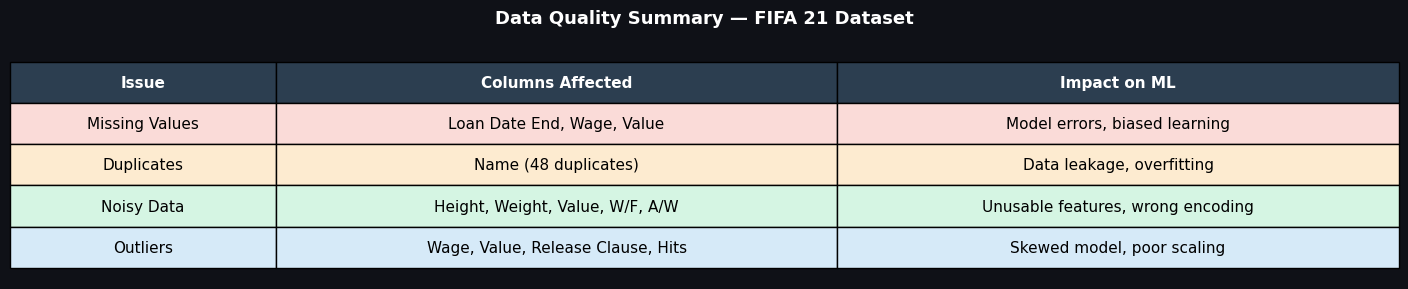

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Summary Table Data ────────────────────────────────────
data = {
    'Issue': [
        'Missing Values',
        'Duplicates',
        'Noisy Data',
        'Outliers'
    ],
    'Columns Affected': [
        'Loan Date End, Wage, Value',
        'Name (48 duplicates)',
        'Height, Weight, Value, W/F, A/W',
        'Wage, Value, Release Clause, Hits'
    ],
    'Impact on ML': [
        'Model errors, biased learning',
        'Data leakage, overfitting',
        'Unusable features, wrong encoding',
        'Skewed model, poor scaling'
    ]
}

df_summary = pd.DataFrame(data)

# ── Print as text table ───────────────────────────────────
# print(df_summary.to_string(index=False))

# ── Visualize as matplotlib table ────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')

table = ax.table(
    cellText  = df_summary.values,
    colLabels = df_summary.columns,
    cellLoc   = 'center',
    loc       = 'center',
    colWidths = [0.18, 0.38, 0.38]
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.5)

# ── Header row styling ────────────────────────────────────
for col in range(3):
    table[0, col].set_facecolor('#2c3e50')
    table[0, col].set_text_props(color='white', fontweight='bold')

# ── Row colors ────────────────────────────────────────────
row_colors = ['#FADBD8', '#FDEBD0', '#D5F5E3', '#D6EAF8']

for row in range(1, 5):
    for col in range(3):
        table[row, col].set_facecolor(row_colors[row - 1])
        table[row, col].set_text_props(color='black') # Set text color for rows

plt.title('Data Quality Summary — FIFA 21 Dataset',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**1. Missing Values**
- Columns like `Loan Date End`, `Wage`, and `Value` contain missing entries
- ML algorithms like Linear Regression cannot handle `NaN` and will crash during training
- Missing values in key columns cause biased learning toward high-profile players only
- Removing rows with missing data reduces the dataset below 18,979 records
- Statistical measures like mean and std silently skip `NaN`, giving misleading EDA results

---

**2. Duplicate Records**
- 48 players appear more than once with different column values
- Same player in both train and test sets causes data leakage, inflating accuracy
- Duplicate rows distort statistics — Messi appearing twice doubles his influence on mean OVA
- Model overfits to specific players instead of learning general patterns

---

**3. Noisy Data**
- Columns like `Height` (170cm), `Value` (€103.5M), `W/F` (4★) are stored as strings — unusable in ML directly
- Invalid entries like `Height = abc` or `Rating = -5` break model training entirely
- Inconsistent labels like `"left"`, `"Left"`, `"LEFT"` are treated as 3 separate categories after encoding
- Out-of-range values like `Age = 200` force the model to fit impossible data points

---

**4. Outliers**
- Columns like `Wage`, `Value`, `Release Clause`, and `Hits` contain extreme values
- Elite players like Messi pull the mean far above what is typical for most players
- Linear Regression shifts toward outlier values, producing poor predictions for average players
- Extreme values compress all others toward zero during normalisation, losing meaningful variation
- IQR detected more outliers than Z-score for skewed columns — method choice matters

Task C - Data Cleaning

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('fifa21_datatset.csv', low_memory=False)

print("=" * 65)
print("   DATA PREPROCESSING & CLEANING")
print("=" * 65)
print(f"\n  Shape BEFORE : {df.shape}")

# ═════════════════════════════════════════════════════════
# STEP 1 : HANDLING MISSING VALUES
# ═════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("   STEP 1 : HANDLING MISSING VALUES")
print("=" * 65)

# ── Before ────────────────────────────────────────────────
print(f"\n  Missing values BEFORE:")
print(df.isnull().sum()[df.isnull().sum() > 0].to_string())

# ── 1a. Drop columns with too many missing values (>50%) ──
threshold = 0.5
cols_to_drop = [col for col in df.columns
                if df[col].isnull().mean() > threshold]
df.drop(columns=cols_to_drop, inplace=True)
print(f"\n  Columns dropped (>50% missing) : {cols_to_drop}")
print(f"  Justification : These columns have too many missing")
print(f"  values to impute reliably. Keeping them would")
print(f"  introduce more noise than information.")

# ── 1b. Drop rows where target (OVA) is missing ───────────
before = df.shape[0]
df.dropna(subset=['↓OVA'], inplace=True)
print(f"\n  Rows dropped (missing OVA) : {before - df.shape[0]}")
print(f"  Justification : Target variable cannot be imputed.")
print(f"  A row without a target is useless for training.")

# ── 1c. Numeric columns → Median imputation ───────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    missing = df[col].isnull().sum()
    if missing > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"\n  [{col}] → Median imputation ({missing} values filled with {median_val})")
        print(f"  Justification : Median is robust to outliers.")
        print(f"  Wage & Value are skewed — median is better than mean.")

# ── 1d. Categorical columns → Mode imputation ─────────────
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    missing = df[col].isnull().sum()
    if missing > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"\n  [{col}] → Mode imputation ({missing} values filled with '{mode_val}')")
        print(f"  Justification : Most frequent value is the best")
        print(f"  guess for categorical columns like Club or Position.")

print(f"\n  Missing values AFTER : {df.isnull().sum().sum()}")

# ═════════════════════════════════════════════════════════
# STEP 2 : FIXING INCONSISTENT DATA
# ═════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("   STEP 2 : FIXING INCONSISTENT DATA")
print("=" * 65)

# ── 2a. Convert Height → numeric (170cm → 170) ────────────
df['Height'] = pd.to_numeric(
    df['Height'].astype(str).str.replace('cm','').str.strip(),
    errors='coerce')
print(f"\n  Height converted to numeric ✅  sample: {df['Height'].head(3).tolist()}")

# ── 2b. Convert Weight → numeric (72kg → 72) ─────────────
df['Weight'] = pd.to_numeric(
    df['Weight'].astype(str).str.replace('kg','').str.strip(),
    errors='coerce')
print(f"  Weight converted to numeric ✅  sample: {df['Weight'].head(3).tolist()}")

# ── 2c. Convert Value / Wage / Release Clause ─────────────
def parse_currency(val):
    if pd.isnull(val): return np.nan
    val = str(val).replace('€','').replace(',','').strip()
    if 'M' in val:   return float(val.replace('M','')) * 1_000_000
    elif 'K' in val: return float(val.replace('K','')) * 1_000
    else:            return float(val) if val else np.nan

for col in ['Value', 'Wage', 'Release Clause']:
    if col in df.columns:
        df[col] = df[col].apply(parse_currency)
        print(f"  {col} converted to numeric ✅  sample: {df[col].head(3).tolist()}")

# ── 2d. Convert W/F, SM, IR → numeric (4★ → 4) ───────────
for col in ['W/F', 'SM', 'IR']:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace('★','').str.strip(),
            errors='coerce')
print(f"  W/F, SM, IR converted to numeric ✅")

# ── 2e. Standardise categorical labels ────────────────────
print(f"\n  Standardising categorical labels:")

# Preferred Foot
print(f"  Preferred Foot before : {df['Preferred Foot'].unique()}")
df['Preferred Foot'] = df['Preferred Foot'].str.strip().str.title()
print(f"  Preferred Foot after  : {df['Preferred Foot'].unique()}")

# A/W and D/W
for col in ['A/W', 'D/W']:
    if col in df.columns:
        print(f"  {col} before : {df[col].unique()}")
        df[col] = df[col].str.strip().str.title()
        print(f"  {col} after  : {df[col].unique()}")

# Best Position
df['Best Position'] = df['Best Position'].str.strip().str.upper()
print(f"  Best Position standardised ✅ ({df['Best Position'].nunique()} unique values)")

# Nationality
df['Nationality'] = df['Nationality'].str.strip().str.title()
print(f"  Nationality standardised ✅ ({df['Nationality'].nunique()} unique values)")

# ── 2f. Remove impossible values ──────────────────────────
print(f"\n  Removing impossible values:")

# Ratings must be 0–100
rating_cols = ['↓OVA','POT','BOV','Crossing','Finishing',
               'Heading Accuracy','Short Passing','Volleys',
               'Dribbling','Curve','FK Accuracy','Long Passing',
               'Ball Control','Acceleration','Sprint Speed',
               'Agility','Reactions','Balance','Shot Power',
               'Jumping','Stamina','Strength','Long Shots',
               'Aggression','Interceptions','Positioning',
               'Vision','Penalties','Composure','Marking',
               'Standing Tackle','Sliding Tackle',
               'GK Diving','GK Handling','GK Kicking',
               'GK Positioning','GK Reflexes',
               'PAC','SHO','PAS','DRI','DEF','PHY']

for col in rating_cols:
    if col in df.columns:
        out = ((df[col] < 0) | (df[col] > 100)).sum()
        if out > 0:
            df.loc[(df[col] < 0) | (df[col] > 100), col] = np.nan
            print(f"  ⚠️  {col} : {out} impossible values removed")

# Age 15–50
out_age = ((df['Age'] < 15) | (df['Age'] > 50)).sum()
df.loc[(df['Age'] < 15) | (df['Age'] > 50), 'Age'] = np.nan
print(f"  Age  : {out_age} impossible values removed (outside 15–50)")

# Height 140–220 cm
out_h = ((df['Height'] < 140) | (df['Height'] > 220)).sum()
df.loc[(df['Height'] < 140) | (df['Height'] > 220), 'Height'] = np.nan
print(f"  Height : {out_h} impossible values removed (outside 140–220 cm)")

# Weight 40–120 kg
out_w = ((df['Weight'] < 40) | (df['Weight'] > 120)).sum()
df.loc[(df['Weight'] < 40) | (df['Weight'] > 120), 'Weight'] = np.nan
print(f"  Weight : {out_w} impossible values removed (outside 40–120 kg)")

print(f"\n  ✅ All impossible values replaced with NaN")

# ═════════════════════════════════════════════════════════
# STEP 3 : REMOVING DUPLICATES
# ═════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("   STEP 3 : REMOVING DUPLICATES")
print("=" * 65)

print(f"\n  Shape before duplicate removal : {df.shape}")

# Full row duplicates
full_dups = df.duplicated().sum()
print(f"\n  Full duplicate rows detected   : {full_dups}")
df = df.drop_duplicates()
print(f"  Full duplicate rows removed    : {full_dups}")

# Duplicate Names — keep highest OVA
name_dups = df.duplicated(subset=['Name']).sum()
print(f"\n  Duplicate Names detected       : {name_dups}")
df = df.sort_values('↓OVA', ascending=False) \
       .drop_duplicates(subset=['Name'], keep='first') \
       .reset_index(drop=True)
print(f"  Duplicate Names removed        : {name_dups}")
print(f"  Strategy : Kept row with highest OVA for each player")

# Duplicate LongNames
long_dups = df.duplicated(subset=['LongName']).sum()
print(f"\n  Duplicate LongNames detected   : {long_dups}")
df = df.drop_duplicates(subset=['LongName'], keep='first') \
       .reset_index(drop=True)
print(f"  Duplicate LongNames removed    : {long_dups}")

print(f"\n  Shape after duplicate removal  : {df.shape}")
print(f"  Total rows removed             : {18979 - df.shape[0]}")

# ── Final Summary ─────────────────────────────────────────
print("\n" + "=" * 65)
print("   FINAL PREPROCESSING SUMMARY")
print("=" * 65)
print(f"""
  Step 1 — Missing Values
    • Dropped columns with >50% missing       : {len(cols_to_drop)}
    • Numeric columns → Median imputation
    • Categorical columns → Mode imputation
    • Remaining missing values               : {df.isnull().sum().sum()}

  Step 2 — Inconsistent Data
    • Height, Weight converted to numeric
    • Value, Wage, Release Clause parsed to float
    • W/F, SM, IR star ratings → integer
    • Preferred Foot, A/W, D/W standardised
    • Impossible values replaced with NaN

  Step 3 — Duplicates
    • Full duplicate rows removed            : {full_dups}
    • Duplicate Names removed                : {name_dups}
    • Duplicate LongNames removed            : {long_dups}

  Original shape  : (18979, 77)
  Final shape     : {df.shape}
""")
print("=" * 65)
print("   END OF PREPROCESSING")
print("=" * 65)